# Fashion MNIST GAN Presentation

### Presented by:
- **Name**: Abhinav Singh (22UCS004)
- **Name**: Yash Gupta (22UCS231)

### Introduction
This project implements a Conditional Generative Adversarial Network (GAN) using the Fashion MNIST dataset. The goal is to generate new fashion items based on specific class labels, allowing for the generation of images that correspond to different categories of clothing.

### Setup Instructions
To run this notebook, ensure you have the following packages installed. This notebook was trained on **PyTorch version 2.6.0+cu126 with CUDA 12.6.** Run the following commands in your terminal:

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
pip install jupyter matplotlib numpy
```

### Import Necessary Libraries
The following libraries are imported for the implementation:

In [15]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import os


### Check CUDA Availability
The code checks if CUDA is available for GPU acceleration:

In [16]:
print(f"Pytorch Version: {torch.__version__}")
print(f"Cuda version: {torch.version.cuda}")
print(f"Is CUDA version availaible: {torch.cuda.is_available()}")

# Check CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Pytorch Version: 2.6.0+cu126
Cuda version: 12.6
Is CUDA version availaible: True
Using device: cuda


### Hyperparameters
The following hyperparameters are defined for the training process:

In [ ]:

# Hyperparameters
batch_size = 128
latent_dim = 175
lr = 0.0002
epochs = 500
num_classes = 10

# 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'


### Load MNIST Dataset
The Fashion MNIST dataset is loaded and transformed:

In [18]:

# Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True
)



### Model Architecture

#### Conditional Generator
The Conditional Generator is defined as follows:

In [19]:
class ConditionalGenerator(nn.Module):  # Changed from Generator
    def __init__(self, latent_dim, num_classes):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embedding = self.label_emb(labels)
        x = torch.cat([z, label_embedding], dim=1)
        return self.model(x).view(-1, 1, 28, 28)



#### Conditional Discriminator
The Conditional Discriminator is defined as follows:


In [20]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(784 + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        label_embedding = self.label_emb(labels)
        x = torch.cat([img_flat, label_embedding], dim=1)
        return self.model(x)

### Training Process
The training loop consists of alternating between training the discriminator and the generator. The loss functions used are Binary Cross Entropy Loss.

[Epoch 1/500] D_loss: 0.3693 G_loss: 6.6517
[Epoch 2/500] D_loss: 0.3644 G_loss: 8.2495
[Epoch 3/500] D_loss: 0.3530 G_loss: 8.5301
[Epoch 4/500] D_loss: 0.3876 G_loss: 10.6206
[Epoch 5/500] D_loss: 0.3922 G_loss: 8.9685
[Epoch 6/500] D_loss: 0.6787 G_loss: 5.0074
[Epoch 7/500] D_loss: 0.7110 G_loss: 4.1513
[Epoch 8/500] D_loss: 0.9273 G_loss: 3.0864
[Epoch 9/500] D_loss: 0.7134 G_loss: 4.9359
[Epoch 10/500] D_loss: 0.7057 G_loss: 3.9137
[Epoch 11/500] D_loss: 0.6547 G_loss: 3.2796
[Epoch 12/500] D_loss: 0.8931 G_loss: 3.1872
[Epoch 13/500] D_loss: 0.8706 G_loss: 3.1570
[Epoch 14/500] D_loss: 0.8036 G_loss: 2.9018
[Epoch 15/500] D_loss: 1.0976 G_loss: 1.9059
[Epoch 16/500] D_loss: 1.0196 G_loss: 2.6282
[Epoch 17/500] D_loss: 0.8468 G_loss: 3.2874
[Epoch 18/500] D_loss: 0.8853 G_loss: 3.3039
[Epoch 19/500] D_loss: 1.1017 G_loss: 1.8453
[Epoch 20/500] D_loss: 0.9432 G_loss: 2.8421


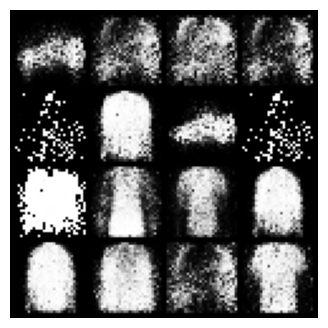

[Epoch 21/500] D_loss: 1.1063 G_loss: 2.2096
[Epoch 22/500] D_loss: 1.0561 G_loss: 2.1223
[Epoch 23/500] D_loss: 0.9105 G_loss: 2.9451
[Epoch 24/500] D_loss: 0.9553 G_loss: 3.2513
[Epoch 25/500] D_loss: 1.0969 G_loss: 2.1194
[Epoch 26/500] D_loss: 1.1407 G_loss: 2.8288
[Epoch 27/500] D_loss: 0.8160 G_loss: 3.2065
[Epoch 28/500] D_loss: 0.9265 G_loss: 2.5558
[Epoch 29/500] D_loss: 0.8299 G_loss: 3.1554
[Epoch 30/500] D_loss: 0.8944 G_loss: 2.5918
[Epoch 31/500] D_loss: 1.0067 G_loss: 3.0391
[Epoch 32/500] D_loss: 1.0002 G_loss: 2.4889
[Epoch 33/500] D_loss: 0.9473 G_loss: 2.7806
[Epoch 34/500] D_loss: 0.8689 G_loss: 2.9262
[Epoch 35/500] D_loss: 1.0299 G_loss: 2.2001
[Epoch 36/500] D_loss: 0.9986 G_loss: 2.2382
[Epoch 37/500] D_loss: 1.0220 G_loss: 2.5224
[Epoch 38/500] D_loss: 1.0288 G_loss: 2.4827
[Epoch 39/500] D_loss: 0.9848 G_loss: 2.2436
[Epoch 40/500] D_loss: 0.9379 G_loss: 1.9433


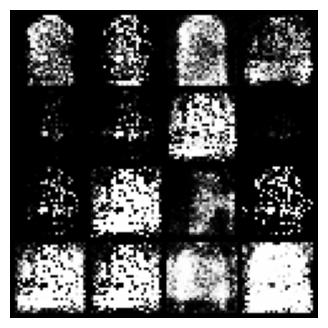

[Epoch 41/500] D_loss: 0.9539 G_loss: 1.9569
[Epoch 42/500] D_loss: 1.0822 G_loss: 1.8905
[Epoch 43/500] D_loss: 1.1087 G_loss: 1.5350
[Epoch 44/500] D_loss: 1.1699 G_loss: 1.9443
[Epoch 45/500] D_loss: 1.0748 G_loss: 1.6155
[Epoch 46/500] D_loss: 1.1925 G_loss: 1.8308
[Epoch 47/500] D_loss: 0.9553 G_loss: 2.4640
[Epoch 48/500] D_loss: 1.0011 G_loss: 1.9104
[Epoch 49/500] D_loss: 1.1956 G_loss: 1.8378
[Epoch 50/500] D_loss: 0.9796 G_loss: 1.8694
[Epoch 51/500] D_loss: 1.0567 G_loss: 2.0804
[Epoch 52/500] D_loss: 1.0122 G_loss: 1.9484
[Epoch 53/500] D_loss: 1.0175 G_loss: 1.7527
[Epoch 54/500] D_loss: 0.9697 G_loss: 1.8956
[Epoch 55/500] D_loss: 0.8912 G_loss: 1.8802
[Epoch 56/500] D_loss: 1.0630 G_loss: 1.7221
[Epoch 57/500] D_loss: 1.0510 G_loss: 1.6226
[Epoch 58/500] D_loss: 1.0874 G_loss: 1.6445
[Epoch 59/500] D_loss: 0.9634 G_loss: 1.7341
[Epoch 60/500] D_loss: 1.1184 G_loss: 1.6542


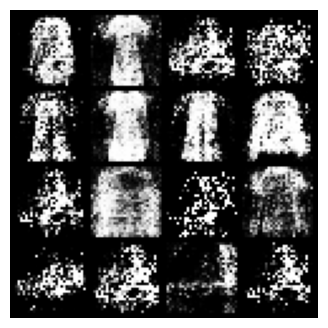

[Epoch 61/500] D_loss: 1.0475 G_loss: 1.7045
[Epoch 62/500] D_loss: 1.0610 G_loss: 1.6306
[Epoch 63/500] D_loss: 1.0064 G_loss: 1.7645
[Epoch 64/500] D_loss: 1.2668 G_loss: 1.1336
[Epoch 65/500] D_loss: 1.1042 G_loss: 1.5922
[Epoch 66/500] D_loss: 0.9960 G_loss: 1.6113
[Epoch 67/500] D_loss: 1.0956 G_loss: 1.3495
[Epoch 68/500] D_loss: 1.0732 G_loss: 1.3548
[Epoch 69/500] D_loss: 1.0821 G_loss: 1.2834
[Epoch 70/500] D_loss: 1.0410 G_loss: 1.6486
[Epoch 71/500] D_loss: 1.1658 G_loss: 1.4053
[Epoch 72/500] D_loss: 1.0804 G_loss: 1.5077
[Epoch 73/500] D_loss: 1.1177 G_loss: 1.4339
[Epoch 74/500] D_loss: 1.1126 G_loss: 1.1745
[Epoch 75/500] D_loss: 1.1794 G_loss: 1.2687
[Epoch 76/500] D_loss: 1.1969 G_loss: 1.2822
[Epoch 77/500] D_loss: 1.1034 G_loss: 1.4855
[Epoch 78/500] D_loss: 1.1829 G_loss: 1.2627
[Epoch 79/500] D_loss: 1.2216 G_loss: 1.2726
[Epoch 80/500] D_loss: 1.1864 G_loss: 1.2885


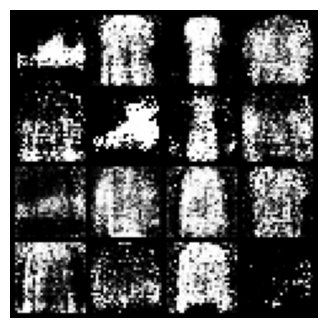

[Epoch 81/500] D_loss: 1.2095 G_loss: 1.0936
[Epoch 82/500] D_loss: 1.1157 G_loss: 1.2674
[Epoch 83/500] D_loss: 1.2304 G_loss: 1.3860
[Epoch 84/500] D_loss: 1.2429 G_loss: 1.2651
[Epoch 85/500] D_loss: 1.2849 G_loss: 1.1436
[Epoch 86/500] D_loss: 1.0639 G_loss: 1.4655
[Epoch 87/500] D_loss: 1.2504 G_loss: 1.2459
[Epoch 88/500] D_loss: 1.2132 G_loss: 1.0627
[Epoch 89/500] D_loss: 1.0112 G_loss: 1.4111
[Epoch 90/500] D_loss: 1.2038 G_loss: 1.2002
[Epoch 91/500] D_loss: 1.1447 G_loss: 1.2169
[Epoch 92/500] D_loss: 1.1284 G_loss: 1.2801
[Epoch 93/500] D_loss: 1.1043 G_loss: 1.1802
[Epoch 94/500] D_loss: 1.1843 G_loss: 1.2865
[Epoch 95/500] D_loss: 1.2491 G_loss: 1.2113
[Epoch 96/500] D_loss: 1.1318 G_loss: 1.3285
[Epoch 97/500] D_loss: 1.2200 G_loss: 1.1340
[Epoch 98/500] D_loss: 1.1367 G_loss: 1.2072
[Epoch 99/500] D_loss: 1.1921 G_loss: 1.1832
[Epoch 100/500] D_loss: 1.1767 G_loss: 1.1111


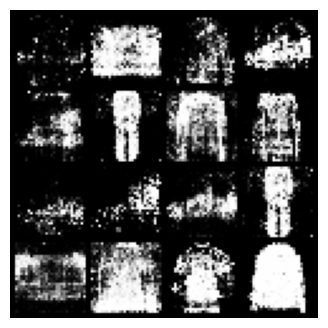

[Epoch 101/500] D_loss: 1.1435 G_loss: 1.2095
[Epoch 102/500] D_loss: 1.2917 G_loss: 1.1926
[Epoch 103/500] D_loss: 1.2046 G_loss: 1.0854
[Epoch 104/500] D_loss: 1.2220 G_loss: 1.1516
[Epoch 105/500] D_loss: 1.1705 G_loss: 1.3670
[Epoch 106/500] D_loss: 1.2269 G_loss: 1.1323
[Epoch 107/500] D_loss: 1.2973 G_loss: 1.0850
[Epoch 108/500] D_loss: 1.3406 G_loss: 1.0221
[Epoch 109/500] D_loss: 1.1841 G_loss: 1.0520
[Epoch 110/500] D_loss: 1.2861 G_loss: 1.0863
[Epoch 111/500] D_loss: 1.3389 G_loss: 0.9645
[Epoch 112/500] D_loss: 1.2247 G_loss: 1.1148
[Epoch 113/500] D_loss: 1.2290 G_loss: 1.1654
[Epoch 114/500] D_loss: 1.2578 G_loss: 0.9374
[Epoch 115/500] D_loss: 1.2608 G_loss: 1.2252
[Epoch 116/500] D_loss: 1.3014 G_loss: 0.9870
[Epoch 117/500] D_loss: 1.2645 G_loss: 1.1111
[Epoch 118/500] D_loss: 1.2233 G_loss: 1.1061
[Epoch 119/500] D_loss: 1.3291 G_loss: 1.0597
[Epoch 120/500] D_loss: 1.0946 G_loss: 1.2849


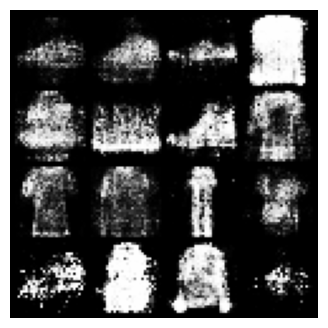

[Epoch 121/500] D_loss: 1.3022 G_loss: 1.0977
[Epoch 122/500] D_loss: 1.3132 G_loss: 0.9405
[Epoch 123/500] D_loss: 1.3420 G_loss: 0.8782
[Epoch 124/500] D_loss: 1.1998 G_loss: 1.0494
[Epoch 125/500] D_loss: 1.3041 G_loss: 0.9787
[Epoch 126/500] D_loss: 1.2187 G_loss: 1.0486
[Epoch 127/500] D_loss: 1.3022 G_loss: 1.0825
[Epoch 128/500] D_loss: 1.2184 G_loss: 1.0652
[Epoch 129/500] D_loss: 1.4079 G_loss: 0.8904
[Epoch 130/500] D_loss: 1.3836 G_loss: 0.9010
[Epoch 131/500] D_loss: 1.3834 G_loss: 0.9524
[Epoch 132/500] D_loss: 1.3615 G_loss: 0.9868
[Epoch 133/500] D_loss: 1.2714 G_loss: 0.9204
[Epoch 134/500] D_loss: 1.3685 G_loss: 0.8795
[Epoch 135/500] D_loss: 1.3101 G_loss: 1.0842
[Epoch 136/500] D_loss: 1.2985 G_loss: 0.9554
[Epoch 137/500] D_loss: 1.3544 G_loss: 0.8923
[Epoch 138/500] D_loss: 1.3090 G_loss: 0.9813
[Epoch 139/500] D_loss: 1.2070 G_loss: 0.9820
[Epoch 140/500] D_loss: 1.2817 G_loss: 0.9234


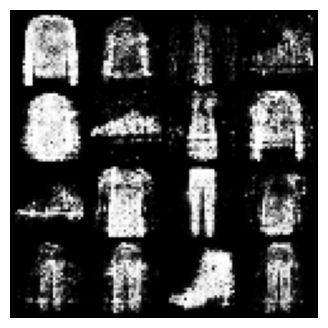

[Epoch 141/500] D_loss: 1.2899 G_loss: 0.9182
[Epoch 142/500] D_loss: 1.3136 G_loss: 1.0344
[Epoch 143/500] D_loss: 1.2983 G_loss: 1.0608
[Epoch 144/500] D_loss: 1.2574 G_loss: 1.0449
[Epoch 145/500] D_loss: 1.3086 G_loss: 0.9670
[Epoch 146/500] D_loss: 1.3963 G_loss: 0.9398
[Epoch 147/500] D_loss: 1.3964 G_loss: 0.8839
[Epoch 148/500] D_loss: 1.3104 G_loss: 0.9585
[Epoch 149/500] D_loss: 1.2989 G_loss: 0.9492
[Epoch 150/500] D_loss: 1.3653 G_loss: 0.9591
[Epoch 151/500] D_loss: 1.2449 G_loss: 0.9645
[Epoch 152/500] D_loss: 1.3239 G_loss: 0.9067
[Epoch 153/500] D_loss: 1.4114 G_loss: 0.8832
[Epoch 154/500] D_loss: 1.3378 G_loss: 1.0272
[Epoch 155/500] D_loss: 1.4036 G_loss: 0.9795
[Epoch 156/500] D_loss: 1.4186 G_loss: 0.9294
[Epoch 157/500] D_loss: 1.1817 G_loss: 1.1586
[Epoch 158/500] D_loss: 1.2719 G_loss: 1.0122
[Epoch 159/500] D_loss: 1.3731 G_loss: 0.9120
[Epoch 160/500] D_loss: 1.4361 G_loss: 0.9726


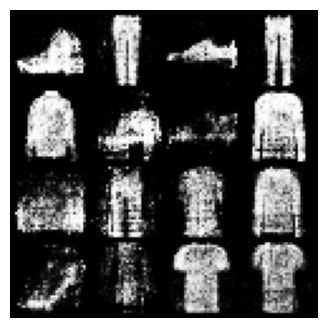

[Epoch 161/500] D_loss: 1.3324 G_loss: 0.9463
[Epoch 162/500] D_loss: 1.4042 G_loss: 0.8929
[Epoch 163/500] D_loss: 1.3587 G_loss: 0.9547
[Epoch 164/500] D_loss: 1.5092 G_loss: 0.8810
[Epoch 165/500] D_loss: 1.3332 G_loss: 1.0511
[Epoch 166/500] D_loss: 1.2401 G_loss: 1.0981
[Epoch 167/500] D_loss: 1.4518 G_loss: 0.8111
[Epoch 168/500] D_loss: 1.2029 G_loss: 1.1068
[Epoch 169/500] D_loss: 1.2825 G_loss: 1.0485
[Epoch 170/500] D_loss: 1.2763 G_loss: 0.8997
[Epoch 171/500] D_loss: 1.2969 G_loss: 0.9673
[Epoch 172/500] D_loss: 1.2899 G_loss: 0.9229
[Epoch 173/500] D_loss: 1.2654 G_loss: 0.9427
[Epoch 174/500] D_loss: 1.2822 G_loss: 0.9423
[Epoch 175/500] D_loss: 1.4034 G_loss: 0.9424
[Epoch 176/500] D_loss: 1.3727 G_loss: 0.8793
[Epoch 177/500] D_loss: 1.2010 G_loss: 0.9765
[Epoch 178/500] D_loss: 1.3531 G_loss: 0.9285
[Epoch 179/500] D_loss: 1.3667 G_loss: 0.9391
[Epoch 180/500] D_loss: 1.3237 G_loss: 0.9314


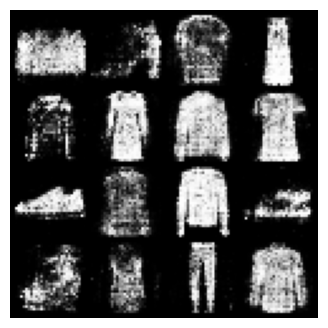

[Epoch 181/500] D_loss: 1.2794 G_loss: 1.0254
[Epoch 182/500] D_loss: 1.2922 G_loss: 0.9915
[Epoch 183/500] D_loss: 1.3136 G_loss: 1.0375
[Epoch 184/500] D_loss: 1.3108 G_loss: 1.0129
[Epoch 185/500] D_loss: 1.3079 G_loss: 0.9038
[Epoch 186/500] D_loss: 1.3062 G_loss: 0.9399
[Epoch 187/500] D_loss: 1.3653 G_loss: 0.8950
[Epoch 188/500] D_loss: 1.3188 G_loss: 0.8868
[Epoch 189/500] D_loss: 1.3683 G_loss: 0.8781
[Epoch 190/500] D_loss: 1.4020 G_loss: 1.0119
[Epoch 191/500] D_loss: 1.4193 G_loss: 0.8371
[Epoch 192/500] D_loss: 1.3549 G_loss: 0.8511
[Epoch 193/500] D_loss: 1.2754 G_loss: 0.9473
[Epoch 194/500] D_loss: 1.4152 G_loss: 0.8794
[Epoch 195/500] D_loss: 1.3348 G_loss: 0.9795
[Epoch 196/500] D_loss: 1.3719 G_loss: 0.9525
[Epoch 197/500] D_loss: 1.3179 G_loss: 0.9337
[Epoch 198/500] D_loss: 1.2671 G_loss: 0.9343
[Epoch 199/500] D_loss: 1.3426 G_loss: 0.8932
[Epoch 200/500] D_loss: 1.3277 G_loss: 0.9380


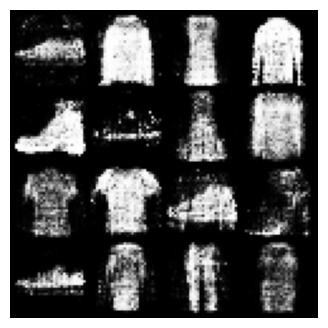

[Epoch 201/500] D_loss: 1.3255 G_loss: 0.9338
[Epoch 202/500] D_loss: 1.2337 G_loss: 1.0378
[Epoch 203/500] D_loss: 1.3813 G_loss: 0.8509
[Epoch 204/500] D_loss: 1.2732 G_loss: 0.9483
[Epoch 205/500] D_loss: 1.3527 G_loss: 0.8742
[Epoch 206/500] D_loss: 1.2694 G_loss: 1.0739
[Epoch 207/500] D_loss: 1.3354 G_loss: 0.9132
[Epoch 208/500] D_loss: 1.2783 G_loss: 1.0640
[Epoch 209/500] D_loss: 1.4252 G_loss: 0.9910
[Epoch 210/500] D_loss: 1.3494 G_loss: 1.0333
[Epoch 211/500] D_loss: 1.2681 G_loss: 0.9634
[Epoch 212/500] D_loss: 1.3179 G_loss: 1.0089
[Epoch 213/500] D_loss: 1.2537 G_loss: 1.0851
[Epoch 214/500] D_loss: 1.3144 G_loss: 1.0466
[Epoch 215/500] D_loss: 1.2491 G_loss: 1.0700
[Epoch 216/500] D_loss: 1.3788 G_loss: 0.9030
[Epoch 217/500] D_loss: 1.4088 G_loss: 0.9012
[Epoch 218/500] D_loss: 1.3724 G_loss: 1.0282
[Epoch 219/500] D_loss: 1.2174 G_loss: 0.9739
[Epoch 220/500] D_loss: 1.3877 G_loss: 1.0591


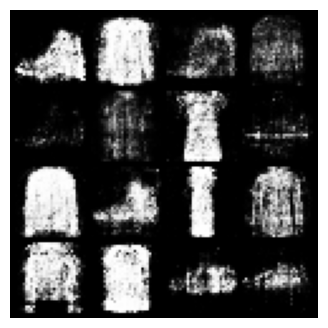

[Epoch 221/500] D_loss: 1.3582 G_loss: 0.8737
[Epoch 222/500] D_loss: 1.3644 G_loss: 0.9984
[Epoch 223/500] D_loss: 1.1989 G_loss: 1.0234
[Epoch 224/500] D_loss: 1.3013 G_loss: 0.9533
[Epoch 225/500] D_loss: 1.3665 G_loss: 0.9008
[Epoch 226/500] D_loss: 1.3603 G_loss: 0.8876
[Epoch 227/500] D_loss: 1.3600 G_loss: 0.9315
[Epoch 228/500] D_loss: 1.3338 G_loss: 0.8740
[Epoch 229/500] D_loss: 1.3626 G_loss: 1.0104
[Epoch 230/500] D_loss: 1.2134 G_loss: 1.0077
[Epoch 231/500] D_loss: 1.2311 G_loss: 0.9599
[Epoch 232/500] D_loss: 1.4419 G_loss: 0.9098
[Epoch 233/500] D_loss: 1.3278 G_loss: 0.9431
[Epoch 234/500] D_loss: 1.4043 G_loss: 0.9101
[Epoch 235/500] D_loss: 1.3261 G_loss: 0.9758
[Epoch 236/500] D_loss: 1.3080 G_loss: 0.9809
[Epoch 237/500] D_loss: 1.3015 G_loss: 0.8763
[Epoch 238/500] D_loss: 1.3494 G_loss: 0.9026
[Epoch 239/500] D_loss: 1.3999 G_loss: 0.9268
[Epoch 240/500] D_loss: 1.4639 G_loss: 0.8372


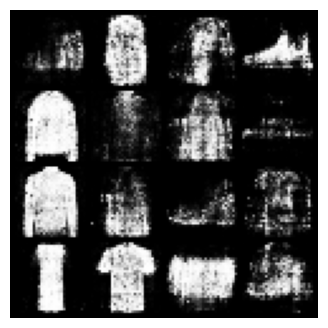

[Epoch 241/500] D_loss: 1.3322 G_loss: 0.8877
[Epoch 242/500] D_loss: 1.3748 G_loss: 1.0097
[Epoch 243/500] D_loss: 1.2694 G_loss: 0.9547
[Epoch 244/500] D_loss: 1.2309 G_loss: 0.9944
[Epoch 245/500] D_loss: 1.3082 G_loss: 0.9569
[Epoch 246/500] D_loss: 1.3176 G_loss: 0.8953
[Epoch 247/500] D_loss: 1.3963 G_loss: 0.8852
[Epoch 248/500] D_loss: 1.2260 G_loss: 1.0071
[Epoch 249/500] D_loss: 1.1898 G_loss: 0.9802
[Epoch 250/500] D_loss: 1.3041 G_loss: 0.9729
[Epoch 251/500] D_loss: 1.2814 G_loss: 0.9022
[Epoch 252/500] D_loss: 1.3364 G_loss: 0.9736
[Epoch 253/500] D_loss: 1.1783 G_loss: 1.0919
[Epoch 254/500] D_loss: 1.2118 G_loss: 1.1950
[Epoch 255/500] D_loss: 1.2363 G_loss: 1.0740
[Epoch 256/500] D_loss: 1.3121 G_loss: 0.9593
[Epoch 257/500] D_loss: 1.2710 G_loss: 0.9754
[Epoch 258/500] D_loss: 1.3163 G_loss: 0.8886
[Epoch 259/500] D_loss: 1.2735 G_loss: 0.9947
[Epoch 260/500] D_loss: 1.2940 G_loss: 0.9592


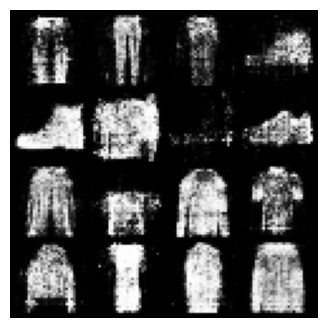

[Epoch 261/500] D_loss: 1.2881 G_loss: 0.9534
[Epoch 262/500] D_loss: 1.2622 G_loss: 0.9176
[Epoch 263/500] D_loss: 1.3276 G_loss: 1.0110
[Epoch 264/500] D_loss: 1.0578 G_loss: 1.1444
[Epoch 265/500] D_loss: 1.2779 G_loss: 0.9673
[Epoch 266/500] D_loss: 1.3315 G_loss: 0.8946
[Epoch 267/500] D_loss: 1.2991 G_loss: 0.9738
[Epoch 268/500] D_loss: 1.3292 G_loss: 1.0040
[Epoch 269/500] D_loss: 1.3578 G_loss: 0.9022
[Epoch 270/500] D_loss: 1.3467 G_loss: 1.0316
[Epoch 271/500] D_loss: 1.4134 G_loss: 0.9309
[Epoch 272/500] D_loss: 1.3813 G_loss: 0.9158
[Epoch 273/500] D_loss: 1.3135 G_loss: 0.9426
[Epoch 274/500] D_loss: 1.2859 G_loss: 0.9703
[Epoch 275/500] D_loss: 1.2601 G_loss: 1.0592
[Epoch 276/500] D_loss: 1.2739 G_loss: 0.9881
[Epoch 277/500] D_loss: 1.2737 G_loss: 1.0011
[Epoch 278/500] D_loss: 1.3247 G_loss: 0.8692
[Epoch 279/500] D_loss: 1.2366 G_loss: 0.9518
[Epoch 280/500] D_loss: 1.3976 G_loss: 0.9146


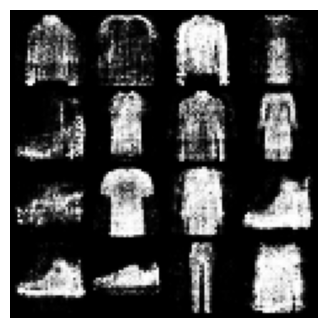

[Epoch 281/500] D_loss: 1.2685 G_loss: 1.2212
[Epoch 282/500] D_loss: 1.2920 G_loss: 0.8964
[Epoch 283/500] D_loss: 1.3514 G_loss: 0.8733
[Epoch 284/500] D_loss: 1.3840 G_loss: 0.8718
[Epoch 285/500] D_loss: 1.2910 G_loss: 0.9344
[Epoch 286/500] D_loss: 1.2300 G_loss: 1.0885
[Epoch 287/500] D_loss: 1.3153 G_loss: 0.9984
[Epoch 288/500] D_loss: 1.3056 G_loss: 0.9007
[Epoch 289/500] D_loss: 1.4425 G_loss: 0.8869
[Epoch 290/500] D_loss: 1.4152 G_loss: 0.8896
[Epoch 291/500] D_loss: 1.2816 G_loss: 1.1009
[Epoch 292/500] D_loss: 1.3797 G_loss: 0.9131
[Epoch 293/500] D_loss: 1.3222 G_loss: 0.8687
[Epoch 294/500] D_loss: 1.3622 G_loss: 0.8889
[Epoch 295/500] D_loss: 1.2781 G_loss: 0.9170
[Epoch 296/500] D_loss: 1.3163 G_loss: 1.0272
[Epoch 297/500] D_loss: 1.3437 G_loss: 0.9122
[Epoch 298/500] D_loss: 1.3104 G_loss: 0.9529
[Epoch 299/500] D_loss: 1.2930 G_loss: 0.9176
[Epoch 300/500] D_loss: 1.4707 G_loss: 0.8871


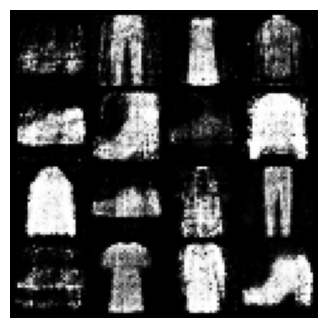

[Epoch 301/500] D_loss: 1.2542 G_loss: 1.0427
[Epoch 302/500] D_loss: 1.2753 G_loss: 1.0309
[Epoch 303/500] D_loss: 1.2614 G_loss: 0.9682
[Epoch 304/500] D_loss: 1.3495 G_loss: 0.8492
[Epoch 305/500] D_loss: 1.1698 G_loss: 1.2298
[Epoch 306/500] D_loss: 1.2822 G_loss: 0.9585
[Epoch 307/500] D_loss: 1.4034 G_loss: 0.8528
[Epoch 308/500] D_loss: 1.3318 G_loss: 0.9558
[Epoch 309/500] D_loss: 1.3986 G_loss: 0.9920
[Epoch 310/500] D_loss: 1.2968 G_loss: 0.9885
[Epoch 311/500] D_loss: 1.2384 G_loss: 0.9838
[Epoch 312/500] D_loss: 1.4012 G_loss: 0.8469
[Epoch 313/500] D_loss: 1.2972 G_loss: 0.9835
[Epoch 314/500] D_loss: 1.3623 G_loss: 0.8984
[Epoch 315/500] D_loss: 1.3298 G_loss: 0.8625
[Epoch 316/500] D_loss: 1.3953 G_loss: 0.8857
[Epoch 317/500] D_loss: 1.2770 G_loss: 0.8724
[Epoch 318/500] D_loss: 1.3865 G_loss: 0.8467
[Epoch 319/500] D_loss: 1.4156 G_loss: 0.8374
[Epoch 320/500] D_loss: 1.3607 G_loss: 0.9134


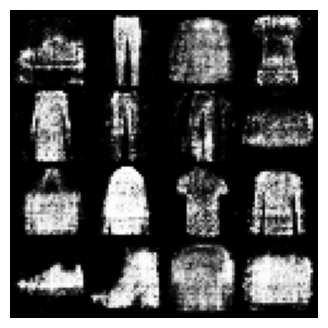

[Epoch 321/500] D_loss: 1.3348 G_loss: 0.9667
[Epoch 322/500] D_loss: 1.1428 G_loss: 1.1055
[Epoch 323/500] D_loss: 1.2490 G_loss: 0.9965
[Epoch 324/500] D_loss: 1.3225 G_loss: 0.9279
[Epoch 325/500] D_loss: 1.3532 G_loss: 0.9011
[Epoch 326/500] D_loss: 1.3621 G_loss: 0.8761
[Epoch 327/500] D_loss: 1.4263 G_loss: 0.9291
[Epoch 328/500] D_loss: 1.4105 G_loss: 0.8508
[Epoch 329/500] D_loss: 1.3040 G_loss: 0.9373
[Epoch 330/500] D_loss: 1.3254 G_loss: 0.9361
[Epoch 331/500] D_loss: 1.3450 G_loss: 0.9794
[Epoch 332/500] D_loss: 1.2848 G_loss: 1.0716
[Epoch 333/500] D_loss: 1.3927 G_loss: 0.8864
[Epoch 334/500] D_loss: 1.4685 G_loss: 0.8341
[Epoch 335/500] D_loss: 1.2009 G_loss: 0.9771
[Epoch 336/500] D_loss: 1.2915 G_loss: 0.9375
[Epoch 337/500] D_loss: 1.4220 G_loss: 0.9013
[Epoch 338/500] D_loss: 1.3165 G_loss: 0.9425
[Epoch 339/500] D_loss: 1.3717 G_loss: 0.8856
[Epoch 340/500] D_loss: 1.3932 G_loss: 0.9327


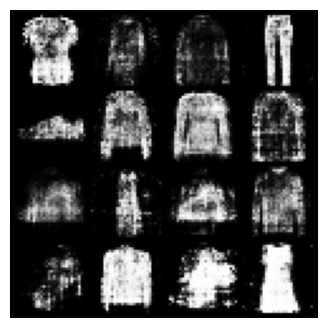

[Epoch 341/500] D_loss: 1.3172 G_loss: 0.9123
[Epoch 342/500] D_loss: 1.4241 G_loss: 0.9926
[Epoch 343/500] D_loss: 1.2449 G_loss: 0.9486
[Epoch 344/500] D_loss: 1.3840 G_loss: 0.8546
[Epoch 345/500] D_loss: 1.2108 G_loss: 1.0615
[Epoch 346/500] D_loss: 1.3462 G_loss: 0.9240
[Epoch 347/500] D_loss: 1.4324 G_loss: 0.8213
[Epoch 348/500] D_loss: 1.2328 G_loss: 0.9441
[Epoch 349/500] D_loss: 1.5145 G_loss: 0.9361
[Epoch 350/500] D_loss: 1.3421 G_loss: 0.8943
[Epoch 351/500] D_loss: 1.3214 G_loss: 0.9009
[Epoch 352/500] D_loss: 1.2598 G_loss: 1.0299
[Epoch 353/500] D_loss: 1.2295 G_loss: 0.9790
[Epoch 354/500] D_loss: 1.4272 G_loss: 1.0597
[Epoch 355/500] D_loss: 1.4048 G_loss: 0.9236
[Epoch 356/500] D_loss: 1.3033 G_loss: 0.9164
[Epoch 357/500] D_loss: 1.2489 G_loss: 1.0083
[Epoch 358/500] D_loss: 1.3396 G_loss: 0.9057
[Epoch 359/500] D_loss: 1.2110 G_loss: 1.0736
[Epoch 360/500] D_loss: 1.3179 G_loss: 0.9362


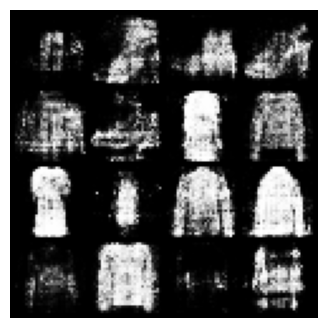

[Epoch 361/500] D_loss: 1.3487 G_loss: 1.0352
[Epoch 362/500] D_loss: 1.4915 G_loss: 1.0007
[Epoch 363/500] D_loss: 1.3348 G_loss: 0.9021
[Epoch 364/500] D_loss: 1.3081 G_loss: 0.9148
[Epoch 365/500] D_loss: 1.3504 G_loss: 0.9278
[Epoch 366/500] D_loss: 1.3532 G_loss: 0.9398
[Epoch 367/500] D_loss: 1.2958 G_loss: 0.8917
[Epoch 368/500] D_loss: 1.5098 G_loss: 0.7871
[Epoch 369/500] D_loss: 1.4147 G_loss: 0.9275
[Epoch 370/500] D_loss: 1.2971 G_loss: 0.8657
[Epoch 371/500] D_loss: 1.3649 G_loss: 0.8568
[Epoch 372/500] D_loss: 1.3875 G_loss: 0.8715
[Epoch 373/500] D_loss: 1.3218 G_loss: 0.8520
[Epoch 374/500] D_loss: 1.3610 G_loss: 0.9090
[Epoch 375/500] D_loss: 1.1881 G_loss: 1.0248
[Epoch 376/500] D_loss: 1.3404 G_loss: 1.0635
[Epoch 377/500] D_loss: 1.3513 G_loss: 0.8984
[Epoch 378/500] D_loss: 1.2614 G_loss: 1.0172
[Epoch 379/500] D_loss: 1.3311 G_loss: 0.9552
[Epoch 380/500] D_loss: 1.3519 G_loss: 0.9167


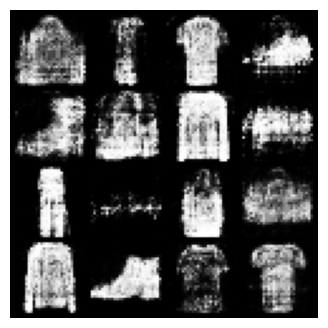

[Epoch 381/500] D_loss: 1.2591 G_loss: 0.9584
[Epoch 382/500] D_loss: 1.4720 G_loss: 0.8224
[Epoch 383/500] D_loss: 1.2830 G_loss: 0.9776
[Epoch 384/500] D_loss: 1.3305 G_loss: 0.9756
[Epoch 385/500] D_loss: 1.3491 G_loss: 0.9781
[Epoch 386/500] D_loss: 1.2400 G_loss: 0.9395
[Epoch 387/500] D_loss: 1.3665 G_loss: 0.8542
[Epoch 388/500] D_loss: 1.3389 G_loss: 0.8658
[Epoch 389/500] D_loss: 1.2926 G_loss: 0.9722
[Epoch 390/500] D_loss: 1.3602 G_loss: 1.0211
[Epoch 391/500] D_loss: 1.2956 G_loss: 0.9398
[Epoch 392/500] D_loss: 1.4123 G_loss: 0.9436
[Epoch 393/500] D_loss: 1.2738 G_loss: 1.0281
[Epoch 394/500] D_loss: 1.3297 G_loss: 0.8690
[Epoch 395/500] D_loss: 1.4611 G_loss: 0.9547
[Epoch 396/500] D_loss: 1.4064 G_loss: 0.8681
[Epoch 397/500] D_loss: 1.4491 G_loss: 0.8145
[Epoch 398/500] D_loss: 1.4191 G_loss: 1.0743
[Epoch 399/500] D_loss: 1.3741 G_loss: 0.9135
[Epoch 400/500] D_loss: 1.3078 G_loss: 1.0542


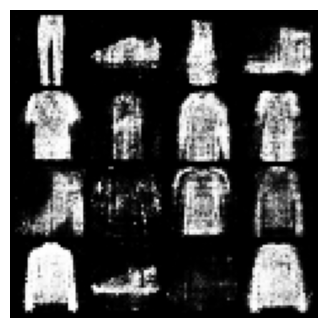

[Epoch 401/500] D_loss: 1.4485 G_loss: 0.9428
[Epoch 402/500] D_loss: 1.3184 G_loss: 0.9099
[Epoch 403/500] D_loss: 1.3163 G_loss: 0.9143
[Epoch 404/500] D_loss: 1.2652 G_loss: 0.9416
[Epoch 405/500] D_loss: 1.5317 G_loss: 0.9108
[Epoch 406/500] D_loss: 1.3911 G_loss: 0.9211
[Epoch 407/500] D_loss: 1.3522 G_loss: 0.9365
[Epoch 408/500] D_loss: 1.3040 G_loss: 0.9945
[Epoch 409/500] D_loss: 1.3960 G_loss: 0.9072
[Epoch 410/500] D_loss: 1.3887 G_loss: 0.8397
[Epoch 411/500] D_loss: 1.4092 G_loss: 0.9579
[Epoch 412/500] D_loss: 1.3960 G_loss: 0.8923
[Epoch 413/500] D_loss: 1.4012 G_loss: 0.8781
[Epoch 414/500] D_loss: 1.2654 G_loss: 0.9778
[Epoch 415/500] D_loss: 1.3591 G_loss: 0.9115
[Epoch 416/500] D_loss: 1.3963 G_loss: 1.0236
[Epoch 417/500] D_loss: 1.4020 G_loss: 0.9082
[Epoch 418/500] D_loss: 1.3614 G_loss: 0.8990
[Epoch 419/500] D_loss: 1.4043 G_loss: 0.8255
[Epoch 420/500] D_loss: 1.3951 G_loss: 0.8779


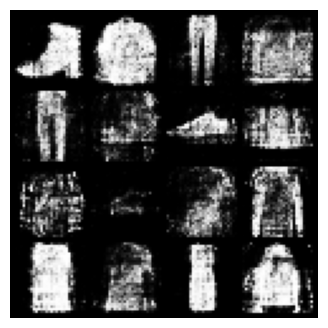

[Epoch 421/500] D_loss: 1.3693 G_loss: 1.0524
[Epoch 422/500] D_loss: 1.3186 G_loss: 1.0330
[Epoch 423/500] D_loss: 1.4762 G_loss: 0.8292
[Epoch 424/500] D_loss: 1.3600 G_loss: 0.9144
[Epoch 425/500] D_loss: 1.4114 G_loss: 0.9791
[Epoch 426/500] D_loss: 1.4067 G_loss: 0.8510
[Epoch 427/500] D_loss: 1.3520 G_loss: 0.8847
[Epoch 428/500] D_loss: 1.3685 G_loss: 0.9497
[Epoch 429/500] D_loss: 1.3617 G_loss: 0.9883
[Epoch 430/500] D_loss: 1.3766 G_loss: 0.9224
[Epoch 431/500] D_loss: 1.3776 G_loss: 0.9483
[Epoch 432/500] D_loss: 1.4470 G_loss: 0.8312
[Epoch 433/500] D_loss: 1.4699 G_loss: 0.9361
[Epoch 434/500] D_loss: 1.3499 G_loss: 0.9800
[Epoch 435/500] D_loss: 1.3408 G_loss: 0.8507
[Epoch 436/500] D_loss: 1.3680 G_loss: 0.8873
[Epoch 437/500] D_loss: 1.2694 G_loss: 0.9609
[Epoch 438/500] D_loss: 1.3557 G_loss: 0.9105
[Epoch 439/500] D_loss: 1.3943 G_loss: 0.8891
[Epoch 440/500] D_loss: 1.3645 G_loss: 0.9111


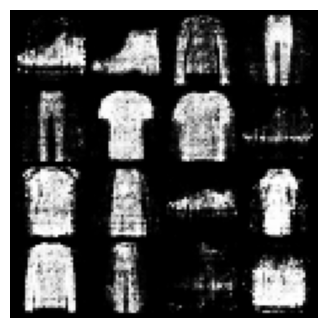

[Epoch 441/500] D_loss: 1.3467 G_loss: 0.9033
[Epoch 442/500] D_loss: 1.2835 G_loss: 0.9274
[Epoch 443/500] D_loss: 1.2957 G_loss: 0.9637
[Epoch 444/500] D_loss: 1.3197 G_loss: 0.9109
[Epoch 445/500] D_loss: 1.3545 G_loss: 0.9035
[Epoch 446/500] D_loss: 1.3456 G_loss: 0.9773
[Epoch 447/500] D_loss: 1.2893 G_loss: 0.9322
[Epoch 448/500] D_loss: 1.3998 G_loss: 0.9436
[Epoch 449/500] D_loss: 1.4120 G_loss: 0.9286
[Epoch 450/500] D_loss: 1.4391 G_loss: 0.7954
[Epoch 451/500] D_loss: 1.3410 G_loss: 0.9830
[Epoch 452/500] D_loss: 1.3552 G_loss: 0.8792
[Epoch 453/500] D_loss: 1.3925 G_loss: 0.8748
[Epoch 454/500] D_loss: 1.3991 G_loss: 0.9164
[Epoch 455/500] D_loss: 1.2625 G_loss: 0.9930
[Epoch 456/500] D_loss: 1.3578 G_loss: 0.8606
[Epoch 457/500] D_loss: 1.3390 G_loss: 0.9566
[Epoch 458/500] D_loss: 1.3851 G_loss: 0.9129
[Epoch 459/500] D_loss: 1.4564 G_loss: 0.8127
[Epoch 460/500] D_loss: 1.2741 G_loss: 0.9167


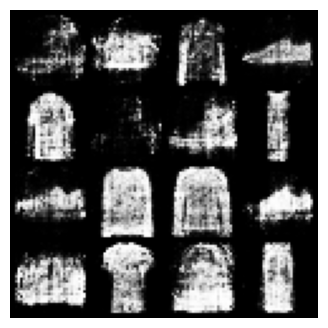

[Epoch 461/500] D_loss: 1.2176 G_loss: 1.1230
[Epoch 462/500] D_loss: 1.3402 G_loss: 0.8982
[Epoch 463/500] D_loss: 1.3461 G_loss: 0.9074
[Epoch 464/500] D_loss: 1.3813 G_loss: 0.8941
[Epoch 465/500] D_loss: 1.4142 G_loss: 0.8347
[Epoch 466/500] D_loss: 1.3966 G_loss: 0.9111
[Epoch 467/500] D_loss: 1.4263 G_loss: 0.9132
[Epoch 468/500] D_loss: 1.2178 G_loss: 1.1534
[Epoch 469/500] D_loss: 1.3433 G_loss: 0.9192
[Epoch 470/500] D_loss: 1.3270 G_loss: 0.8337
[Epoch 471/500] D_loss: 1.3882 G_loss: 0.8408
[Epoch 472/500] D_loss: 1.4012 G_loss: 0.8118
[Epoch 473/500] D_loss: 1.4292 G_loss: 1.0611
[Epoch 474/500] D_loss: 1.4799 G_loss: 0.8627
[Epoch 475/500] D_loss: 1.3131 G_loss: 1.0162
[Epoch 476/500] D_loss: 1.3162 G_loss: 0.9131
[Epoch 477/500] D_loss: 1.3425 G_loss: 0.8639
[Epoch 478/500] D_loss: 1.3030 G_loss: 1.1244
[Epoch 479/500] D_loss: 1.3205 G_loss: 0.8520
[Epoch 480/500] D_loss: 1.3185 G_loss: 0.9942


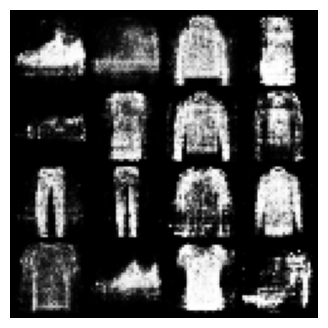

[Epoch 481/500] D_loss: 1.2909 G_loss: 0.9009
[Epoch 482/500] D_loss: 1.4565 G_loss: 0.8767
[Epoch 483/500] D_loss: 1.4078 G_loss: 0.9122
[Epoch 484/500] D_loss: 1.2823 G_loss: 1.0029
[Epoch 485/500] D_loss: 1.3908 G_loss: 0.9079
[Epoch 486/500] D_loss: 1.3759 G_loss: 0.8910
[Epoch 487/500] D_loss: 1.2850 G_loss: 0.8936
[Epoch 488/500] D_loss: 1.4372 G_loss: 0.9144
[Epoch 489/500] D_loss: 1.4064 G_loss: 0.9392
[Epoch 490/500] D_loss: 1.3757 G_loss: 0.9443
[Epoch 491/500] D_loss: 1.1871 G_loss: 1.0447
[Epoch 492/500] D_loss: 1.2339 G_loss: 0.9676
[Epoch 493/500] D_loss: 1.3035 G_loss: 1.0461
[Epoch 494/500] D_loss: 1.5070 G_loss: 0.7867
[Epoch 495/500] D_loss: 1.3052 G_loss: 0.9552
[Epoch 496/500] D_loss: 1.2737 G_loss: 0.9503
[Epoch 497/500] D_loss: 1.3607 G_loss: 0.9049
[Epoch 498/500] D_loss: 1.3475 G_loss: 0.8444
[Epoch 499/500] D_loss: 1.2765 G_loss: 1.0407
[Epoch 500/500] D_loss: 1.3686 G_loss: 0.8408


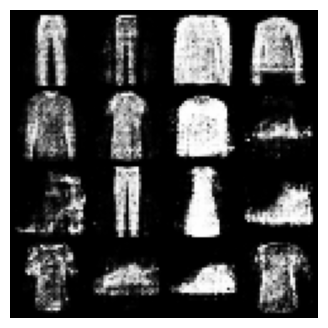

In [21]:
# Initialize models 
generator = ConditionalGenerator(latent_dim, num_classes).to(device)
discriminator = ConditionalDiscriminator(num_classes).to(device)

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

# Loss function (Binary Cross Entropy Loss)
# Note: For conditional GANs, we typically use BCE loss for both generator and discriminator
criterion = nn.BCELoss()  

# Training loop
for epoch in range(epochs):
    for i, (imgs, labels) in enumerate(train_loader):
        real_imgs = imgs.to(device)
        labels = labels.to(device)  # Get actual labels
        

        optimizer_D.zero_grad()
        
        # Real images with real labels
        real_output = discriminator(real_imgs, labels)  # Pass labels here
        d_loss_real = criterion(real_output, torch.ones_like(real_output)*0.9)
        
        # Fake images with same labels
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        fake_imgs = generator(z, labels)
        fake_output = discriminator(fake_imgs.detach(), labels)  # Pass labels here
        d_loss_fake = criterion(fake_output, torch.zeros_like(fake_output)*0.1)
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()
        
        # Generate fake images with same labels
        gen_output = discriminator(fake_imgs, labels)  # Pass labels here
        g_loss = criterion(gen_output, torch.ones_like(gen_output))
        
        g_loss.backward()
        optimizer_G.step()
        
    # Print progress
    print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")
    
    # During training visualization
    if (epoch+1) % 20 == 0:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim).to(device)
            test_labels = torch.randint(0, 10, (16,)).to(device)  # Random labels 0-9
            generated = generator(test_z, test_labels).cpu()  # Add labels here
            
            plt.figure(figsize=(4,4))
            plt.imshow(np.transpose(make_grid(generated, nrow=4, padding=2, normalize=True),(1,2,0)))
            plt.axis('off')
            plt.show()

# Save models
torch.save(generator.state_dict(), 'mnist_fashion_generator.pth')
torch.save(discriminator.state_dict(), 'mnist_fasion_discriminator.pth')

In [22]:
os.makedirs('gan-api/models', exist_ok=True)

torch.save(generator.state_dict(), 'gan-api/models/mnist_fashion_generator.pth')
torch.save(discriminator.state_dict(), 'gan-api/models/mnist_fashion_discriminator.pth')
print('Models saved successfully in gan-api/models directory')

Models saved successfully in gan-api/models directory


### Evaluation
The evaluation function assesses the performance of the GAN by generating images and calculating the accuracy of the discriminator.

Discriminator Accuracy on Real: 0.2422
Discriminator Accuracy on Fake: 0.8700
Total Discriminator Accuracy: 0.5561


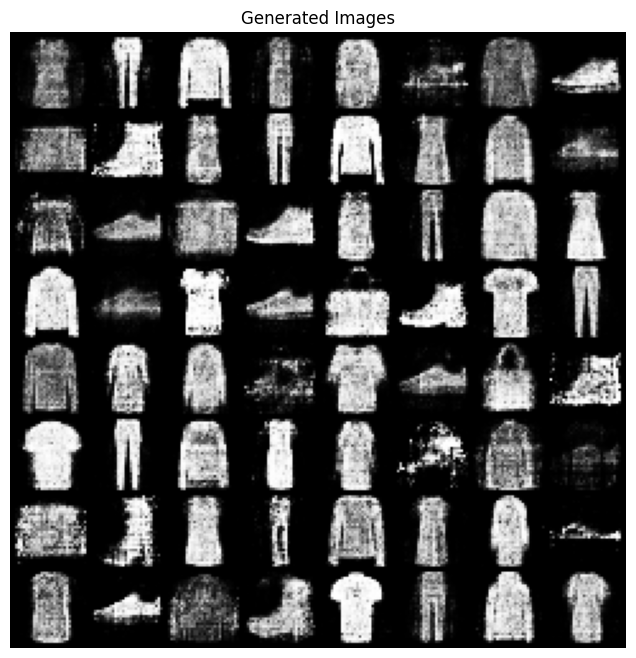

In [23]:
def show_images(images, title="Generated Images"):
    plt.figure(figsize=(8,8))
    plt.title(title)
    plt.axis('off')
    grid = make_grid(images.clamp(-1,1), nrow=8, padding=2, normalize=True)
    plt.imshow(np.transpose(grid.cpu().numpy(), (1,2,0)))
    plt.show()


def evaluate_gan(generator, discriminator, latent_dim, real_images, real_labels, n_samples=1000):
    generator.eval()
    discriminator.eval()
    with torch.no_grad():
        # Generate fake images with random labels
        z = torch.randn(n_samples, latent_dim).to(device)
        fake_labels = torch.randint(0, 10, (n_samples,)).to(device)
        fake_images = generator(z, fake_labels)
        
        # Get real images with their actual labels
        real_labels = real_labels[:n_samples].to(device)
        
        # Calculate discriminator outputs WITH LABELS
        real_output = discriminator(real_images, real_labels)
        fake_output = discriminator(fake_images, fake_labels)
        
        # Calculate discriminator accuracy
        real_acc = (real_output >= 0.5).float().mean()
        fake_acc = (fake_output < 0.5).float().mean()
        total_acc = (real_acc + fake_acc) / 2
        
        test_z = torch.randn(64, latent_dim).to(device)
        test_labels = torch.LongTensor([i % 10 for i in range(64)]).to(device)
        generated = generator(test_z, test_labels).cpu()
        
    print(f"Discriminator Accuracy on Real: {real_acc.item():.4f}")
    print(f"Discriminator Accuracy on Fake: {fake_acc.item():.4f}")
    print(f"Total Discriminator Accuracy: {total_acc.item():.4f}")
    
    show_images(generated)

# Load real images WITH LABELS for evaluation
real_images, real_labels = next(iter(train_loader))
real_images = real_images[:1000].to(device)
real_labels = real_labels[:1000] 

# Run evaluation
evaluate_gan(generator, discriminator, latent_dim, real_images, real_labels)

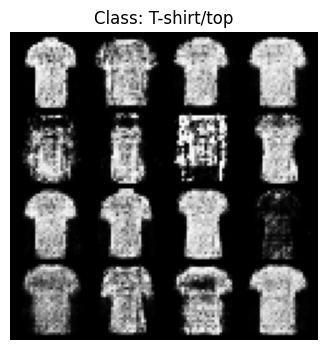

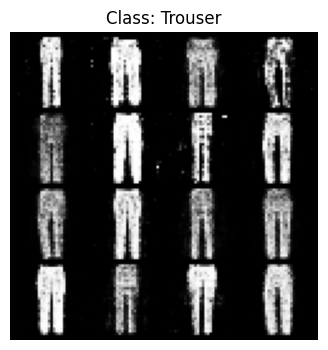

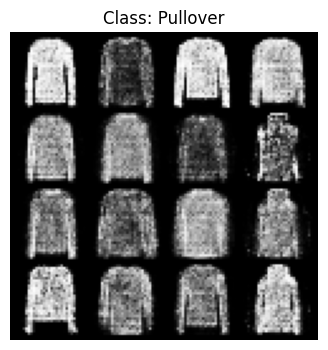

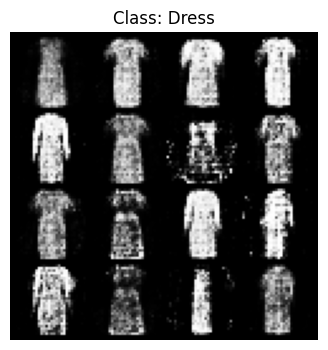

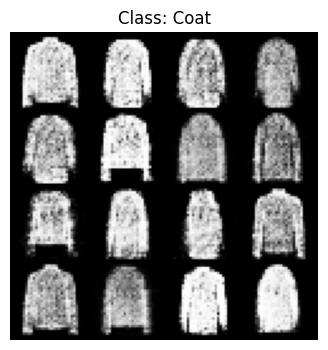

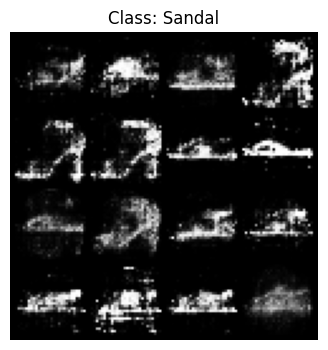

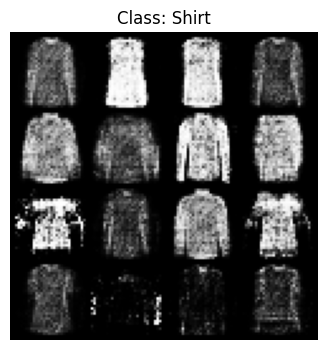

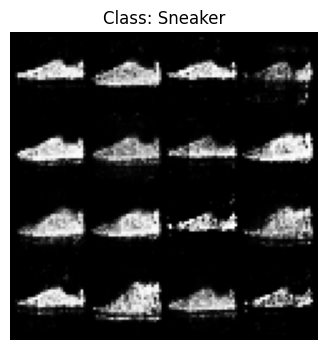

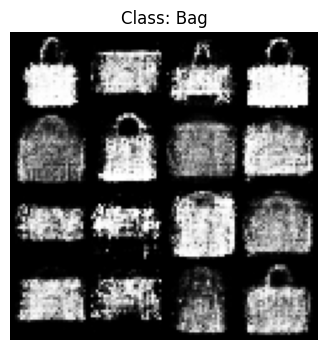

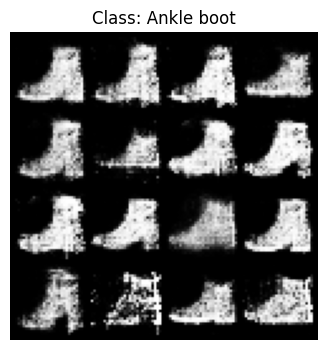

In [24]:
def generate_specific_class(digit: int, num_samples: int = 16):
    generator.eval()
    with torch.no_grad():
        labels = torch.full((num_samples,), digit, dtype=torch.long).to(device)
        z = torch.randn(num_samples, latent_dim).to(device)
        generated = generator(z, labels).cpu()  
        plt.figure(figsize=(4,4))
        plt.imshow(np.transpose(make_grid(generated, nrow=4, padding=2, normalize=True), (1,2,0)))
        plt.title(f"Class: {['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'][digit]}")
        plt.axis('off')
        plt.show()


for i in range(0,10):
    generate_specific_class(digit=i)

## Conclusion
This notebook demonstrates the implementation of a Conditional GAN using the Fashion MNIST dataset. The trained models can generate new fashion items based on specific class labels, showcasing the capabilities of GANs in generating realistic images.
